In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import os
import numpy as np
from task_grn_inference.src.process_data.helper_data import qc_perturbation, pseudobulk_sum_func, normalize_func


In [2]:
def parse_donor_id(s):
    import re
    m = re.match(r'^[A-Za-z](\d+)([MF])([A-Z]+)(\d+)$', s)
    ID = int(m.group(1))
    sex = 'Male' if m.group(2)=='M' else 'Female'
    disease = m.group(3)
    condition_map = {'1':'RPMI','2':'LPS','3':'S. enterica'}
    condition = condition_map.get(m.group(4), m.group(4))
    return pd.Series([ID, sex, disease, condition])

def qc_atac(adata,
            min_fragments=1000, max_fragments=5e4,
            min_features=500, max_features=5e4,
            max_nucleosome_signal=4,
            min_tss_enrichment=2):
    """
    Filter scATAC-seq cells based on common QC metrics.
    Requires columns: nCount_ATAC, nFeature_ATAC, nucleosome_signal, TSS.enrichment
    """
    qc_mask = (
        (adata.obs['nCount_ATAC'] >= min_fragments) &
        (adata.obs['nCount_ATAC'] <= max_fragments) &
        (adata.obs['nFeature_ATAC'] >= min_features) &
        (adata.obs['nFeature_ATAC'] <= max_features) &
        (adata.obs['nucleosome_signal'] <= max_nucleosome_signal) &
        (adata.obs['TSS.enrichment'] >= min_tss_enrichment)
    )

    print(f"Keeping {qc_mask.sum()} cells out of {adata.n_obs}")
    return adata[qc_mask].copy()
map_cell_types = {
    'CD8 T cells': 'CD8T', 
    'CD4 T cells': 'CD4T', 
    'Monocytes': 'MONO', 
    'NK cells': 'NK', 
    'B cells': 'B'
}
def format_adata(adata):
    adata.obs['donorID'] = adata.obs['donorID'].astype(str)
    parsed = adata.obs['donorID'].apply(parse_donor_id)
    parsed.columns = ['ID', 'sex', 'disease', 'condition']
    adata.obs[['ID', 'sex', 'disease', 'condition']] = parsed

    adata.obs = adata.obs[['ID', 'sex', 'disease', 'condition', 'celltype', 'cellID']].rename(
        columns={'celltype':'cell_type', 'ID': 'donor_id', 'condition': 'perturbation', 'cellID': 'barcode', 'poolID': 'pool'}
        )

    df = pd.read_csv("/vol/projects/CIIM/processed/cytokines/IBD/merged_metadata.csv") 
    df = df[['Age', 'IL10', 'ID', 'type', 'stim']].rename(columns={'type':'disease', 'stim': 'perturbation', 'Age': 'age', 'ID': 'donor_id'})
    df = df[~df['perturbation'].isna()]

    stim_map = {'LPS':'LPS', 'NS':'RPMI', 'Sal':'S. enterica', 'S. salmonella': 'S. enterica'}
    df['perturbation'] = df['perturbation'].map(lambda x: stim_map.get(x, x))

    adata.obs['perturbation'] = adata.obs['perturbation'].map(lambda x: stim_map.get(x, x))
    adata.obs = adata.obs.merge(df, on=['donor_id', 'disease', 'perturbation'], how='left')

    adata.obs['cell_type'] = adata.obs['cell_type'].map(map_cell_types).astype('category')
    adata.obs['condition'] = adata.obs['perturbation'].astype('str') + '_' + adata.obs['disease'].astype('str')
    return adata

data_dir = '/vol/projects/CIIM/processed/multiome/IBD/'
save_dir = '/vol/projects/jnourisa/datasets/'
adata_rna = ad.read_h5ad(f'{data_dir}/rna.h5ad')
adata_rna = format_adata(adata_rna)

adata_atac = ad.read_h5ad(f'{data_dir}/atac.h5ad')
adata_atac = qc_atac(adata_atac)
adata_atac = format_adata(adata_atac)

Keeping 98945 cells out of 120361


In [3]:
adata_rna.obs['group_col'] = adata_rna.obs['perturbation'].astype(str) + '_' + adata_rna.obs['cell_type'].astype(str) + '_' + adata_rna.obs['donor_id'].astype(str) 
adata_rna = qc_perturbation(adata_rna, col='group_col', min_cells_per_pert=10, min_cells_per_gene=100, min_genes_per_cell=200)

Kept 391 perturbations (>= 10 cells each) out of 395 total
Kept 18373 genes (>= 100 cells total) out of 24978 total
Kept 120333 cells (>= 200 genes per cell) out of 120333 total


In [4]:
rna_barcodes = set(adata_rna.obs['barcode'])
atac_barcodes = set(adata_atac.obs['barcode'])
common_barcodes = rna_barcodes.intersection(atac_barcodes)
print(f'Common barcodes: {len(common_barcodes)}')
adata_rna = adata_rna[adata_rna.obs['barcode'].isin(common_barcodes)].copy()
adata_atac = adata_atac[adata_atac.obs['barcode'].isin(common_barcodes)].copy()

print(f'Final RNA shape: {adata_rna.shape}')
print(f'Final ATAC shape: {adata_atac.shape}')

Common barcodes: 91545
Final RNA shape: (101071, 18373)
Final ATAC shape: (98928, 182416)


In [5]:
adata_rna = normalize_func(adata_rna)
adata_rna

AnnData object with n_obs × n_vars = 101071 × 18373
    obs: 'donor_id', 'sex', 'disease', 'perturbation', 'cell_type', 'barcode', 'age', 'IL10', 'condition', 'group_col'
    layers: 'lognorm'

In [6]:
adata_rna.write(f'{save_dir}/sc/ibd_rna.h5ad')
adata_atac.write(f'{save_dir}/sc/ibd_atac.h5ad')

In [7]:
adata_rna_bulk = pseudobulk_sum_func(adata_rna, group='group_col')
adata_rna_bulk = normalize_func(adata_rna_bulk)

adata_rna_bulk.write(f'{save_dir}/bulk/ibd_bulk.h5ad')

ratio of missingness 0.4310227574243896


In [8]:
adata_rna_bulk.X = adata_rna_bulk.layers['lognorm']

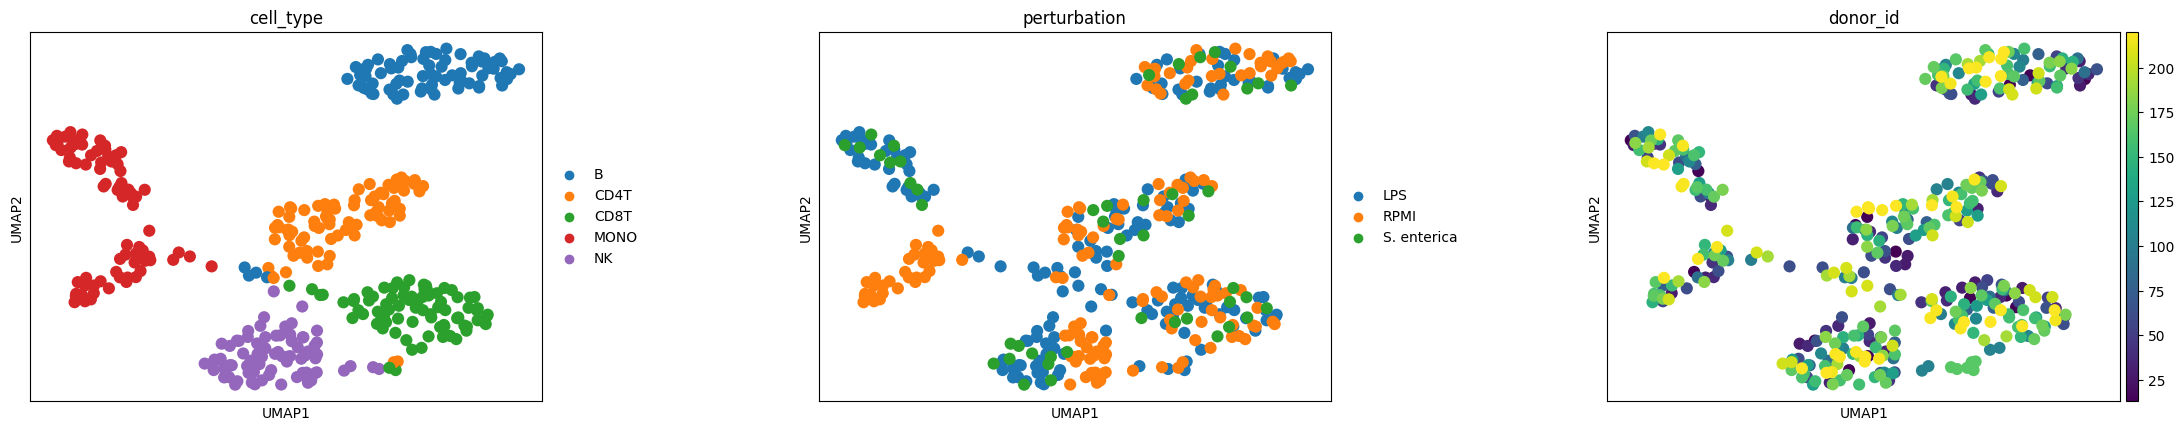

In [9]:

sc.pp.neighbors(adata_rna_bulk, n_neighbors=15, n_pcs=50)

# Run UMAP
sc.tl.umap(adata_rna_bulk)

# Plot colored by a column in obs
sc.pl.umap(adata_rna_bulk, color=['cell_type', 'perturbation', 'donor_id'], wspace=0.4)